### Download dos dados csv diretamente do gov

In [2]:
import os
import urllib.request
import ssl

# 1. Ignorar o aviso de SSL do governo
ssl._create_default_https_context = ssl._create_unverified_context

ocorrencias = "OCORRENCIAS_2025"
url = f"https://servicos.dpf.gov.br/dadosabertos/SINARM_CSV/OCORRENCIAS/{ocorrencias}.csv"
pasta = "sample_data"
caminho_arquivo = f"{pasta}/{ocorrencias}.csv"

# 2. Cria a pasta 'sample_data' caso ela ainda não exista no seu computador
os.makedirs(pasta, exist_ok=True)

# 3. Baixa o arquivo APENAS se ele ainda não estiver salvo na pasta
if not os.path.exists(caminho_arquivo):
    print("Iniciando o download... Isso pode demorar alguns segundos.")
    urllib.request.urlretrieve(url, caminho_arquivo)
    print(f"Download concluído! Arquivo salvo em: {caminho_arquivo}")
else:
    print(f"O arquivo '{caminho_arquivo}' já existe. Não é necessário baixar novamente.")

Iniciando o download... Isso pode demorar alguns segundos.
Download concluído! Arquivo salvo em: sample_data/OCORRENCIAS_2025.csv


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

caminho_arquivo = "sample_data/dataset_limpo.csv"
# caminho_arquivo = f"sample_data/{ocorrencias}.csv"

df = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')

print("Dimensões do Dataset:", df.shape)
display(df.head())

Dimensões do Dataset: (85851, 10)


,ANO_OCORRENCIA,MES_OCORRENCIA,UF,MUNICIPIO,ESPECIE_ARMA,MARCA_ARMA,CALIBRE_ARMA,TIPO_OCORRENCIA,MAIS_1000_MIL_HAB,TOTAL
0,2025,1,AC,ACRELÂNDIA,Espingarda ...,ROSSI (AMADEO ROSSI S.A.) ...,36 ...,Apreensão de Arma de Fogo ...,N,1
1,2025,1,AC,CRUZEIRO DO SUL,Espingarda ...,ROSSI (AMADEO ROSSI S.A.) ...,28 ...,Extravio/Perda de Arma de Fogo ...,N,1
2,2025,1,AC,FEIJÓ,Espingarda ...,CBC (COMPANHIA BRASILEIRA DE CARTUCHOS) ...,28 ...,Extravio/Perda de Arma de Fogo ...,N,1
3,2025,1,AC,RIO BRANCO,Espingarda ...,ROSSI (AMADEO ROSSI S.A.) ...,36/.22LR (duplo cano) ...,Extravio/Perda de Arma de Fogo ...,S,2
4,2025,1,AC,RIO BRANCO,Pistola ...,TAURUS ARMAS S.A. ...,.380 ACP ...,Roubo de Arma de Fogo ...,S,1


In [15]:
# Verificando a qualidade dos dados (objetivo da Sprint 1)
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores Não-Nulos': df.notnull().sum(),
    'Valores Nulos (Vazios)': df.isnull().sum()
})
display(info_df)



,Tipo,Valores Não-Nulos,Valores Nulos (Vazios)
ANO_OCORRENCIA,int64,85851,0
MES_OCORRENCIA,int64,85851,0
UF,object,85851,0
MUNICIPIO,object,85851,0
ESPECIE_ARMA,object,85851,0
MARCA_ARMA,object,85851,0
CALIBRE_ARMA,object,85851,0
TIPO_OCORRENCIA,object,85851,0
MAIS_1000_MIL_HAB,object,85851,0
TOTAL,int64,85851,0


/var/folders/ws/ctml7df92n5fcfhp9nkn28dh0000gn/T/ipykernel_73508/3666633083.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='viridis', ax=axes[0])
/var/folders/ws/ctml7df92n5fcfhp9nkn28dh0000gn/T/ipykernel_73508/3666633083.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=especie_counts.index, x=especie_counts.values, palette='magma', ax=axes[1])


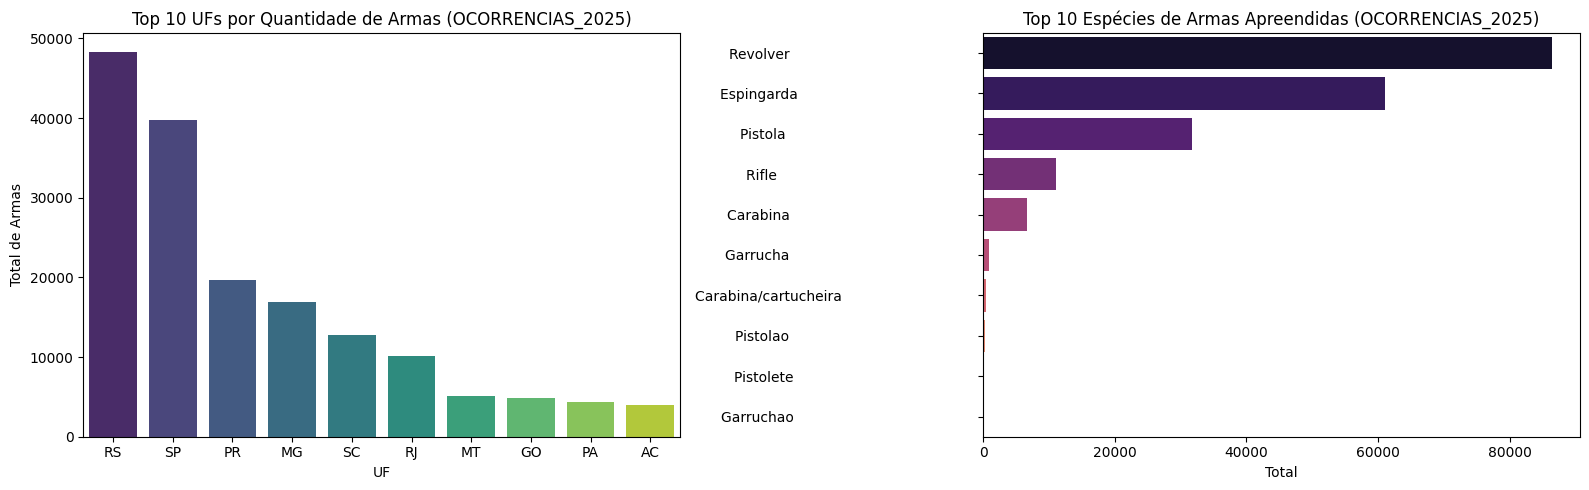

In [16]:
# Preparando os dados para visualização
uf_counts = df.groupby('UF')['TOTAL'].sum().sort_values(ascending=False).head(10)
especie_counts = df.groupby('ESPECIE_ARMA')['TOTAL'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Top UFs
sns.barplot(x=uf_counts.index, y=uf_counts.values, palette='viridis', ax=axes[0])
axes[0].set_title(f'Top 10 UFs por Quantidade de Armas ({ocorrencias})')
axes[0].set_ylabel('Total de Armas')
axes[0].set_xlabel('UF')

# Gráfico 2: Top Espécies
sns.barplot(y=especie_counts.index, x=especie_counts.values, palette='magma', ax=axes[1])
axes[1].set_title(f'Top 10 Espécies de Armas Apreendidas ({ocorrencias})')
axes[1].set_xlabel('Total')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()